# 05 — Reference-model construction, training and results

This notebook is the complete, self-contained RR workflow for the five original 30-minute Queensland demand reference models. It covers model construction, chronological training, fold-contained Ridge tuning, common-sample scoring, diagnostics and publication-ready results.

The public experiment uses only 2015–2020 data. Expanding development evaluations cover 2017, 2018 and 2019; the final public holdout is 2020. No later data are loaded. The direct target is $\Delta D_{t,30}=D_{t+30}-D_t$, and all point metrics are calculated after reconstructing $\widehat D_{t+30}=D_t+\widehat{\Delta D}_{t,30}$.

By default this notebook loads the preserved verified outputs. Full fitting occurs only when `RUN_MODEL_TRAINING = True` and the interactive confirmation is accepted.


## 1. Reproducibility settings and execution guard

In [1]:
from pathlib import Path
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
warnings.filterwarnings("ignore", message="Found unknown categories")
sns.set_theme(context="notebook", style="whitegrid", rc={"figure.dpi": 110})

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == "notebooks" else cwd
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "rr_reference_model_frame_5min_2015_2020.parquet"
CONTRACT_PATH = PROJECT_ROOT / "config" / "reference_model_feature_contract.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "reference_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = [
    "Persistence",
    "Weekly seasonal naive",
    "Comparable-history empirical change",
    "Bayesian random walk",
    "Ridge regression",
]
FORECAST_MINUTES = 30
FORECAST_STEPS = 6
RIDGE_ALPHAS = np.logspace(-4, 4, 17)
INNER_SPLITS = 3
INNER_GAP_ROWS = FORECAST_STEPS
MIN_COMPARABLE_CELL_COUNT = 20

# Safe default: display the preserved, verified outputs. Set True only for an
# explicitly authorised regeneration of the complete four-fold workflow.
RUN_MODEL_TRAINING = False

figure_counter = 0
def figure_caption(text):
    global figure_counter
    figure_counter += 1
    display(Markdown(f"*Figure 05.{figure_counter}. {text}*"))

for required_path in [DATA_PATH, CONTRACT_PATH]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

if RUN_MODEL_TRAINING:
    confirmation = input("Regenerate all reference models? Enter Y to proceed: ").strip().upper()
    if confirmation != "Y":
        RUN_MODEL_TRAINING = False
        print("Training was not confirmed; preserved outputs will be loaded.")
else:
    print("Training disabled; preserved verified outputs will be loaded.")
print(f"Data: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Feature contract: {CONTRACT_PATH.relative_to(PROJECT_ROOT)}")


Training disabled; preserved verified outputs will be loaded.
Data: data\processed\rr_reference_model_frame_5min_2015_2020.parquet
Feature contract: config\reference_model_feature_contract.csv


## 2. Frozen feature contract and public data boundary

The Ridge model uses the original 55 base predictors plus two deterministic calendar encodings. All preprocessing is fitted independently within each outer or inner training fold.

In [2]:
contract = pd.read_csv(CONTRACT_PATH)
include = contract["include_full_ridge"].astype(str).str.lower().isin({"true", "1"})
model_feature_contract = contract.loc[include].copy()

RIDGE_NUMERIC_FEATURES = model_feature_contract.loc[
    model_feature_contract.data_type.eq("numeric"), "canonical_feature_name"
].tolist()
RIDGE_BINARY_FEATURES = model_feature_contract.loc[
    model_feature_contract.data_type.eq("binary"), "canonical_feature_name"
].tolist()
RIDGE_CATEGORICAL_FEATURES = model_feature_contract.loc[
    model_feature_contract.data_type.eq("categorical"), "canonical_feature_name"
].tolist()
RIDGE_FEATURES = RIDGE_NUMERIC_FEATURES + RIDGE_BINARY_FEATURES + RIDGE_CATEGORICAL_FEATURES
assert len(RIDGE_FEATURES) == 55

BASE_COLUMNS = [
    "datetime", "totaldemand_mw", "target_ramp_next_30min",
    "interval_of_day", "is_weekend", "is_public_holiday_qld", "month", "season",
]
READ_COLUMNS = list(dict.fromkeys(BASE_COLUMNS + RIDGE_FEATURES))
df = pd.read_parquet(DATA_PATH, columns=READ_COLUMNS)
df["datetime"] = pd.to_datetime(df["datetime"], errors="raise").astype("datetime64[ns]")
df = df.sort_values("datetime").reset_index(drop=True)

df["calendar_interval_slot"] = df["interval_of_day"].astype("string")
df["calendar_slot_daytype_holiday_month"] = (
    df["interval_of_day"].astype("string") + "|"
    + df["is_weekend"].astype("string") + "|"
    + df["is_public_holiday_qld"].astype("string") + "|"
    + df["month"].astype("string")
)
RIDGE_DERIVED_CALENDAR_FEATURES = [
    "calendar_interval_slot", "calendar_slot_daytype_holiday_month"
]
RIDGE_DESIGN_FEATURES = RIDGE_FEATURES + RIDGE_DERIVED_CALENDAR_FEATURES

assert df.datetime.min() >= pd.Timestamp("2015-01-01")
assert df.datetime.max() < pd.Timestamp("2021-01-01")
assert df.datetime.is_monotonic_increasing and not df.datetime.duplicated().any()
print(f"Loaded {len(df):,} public rows, {len(RIDGE_FEATURES)} base Ridge features, and 2 deterministic calendar terms.")
display(model_feature_contract)


Loaded 631,295 public rows, 55 base Ridge features, and 2 deterministic calendar terms.


,canonical_feature_name,data_type,source_dataset,btcn_channel,forecast_origin_availability,publication_latency,required_transformation,lag_or_sequence_position,missing_value_rule,available_in_deployment,include_full_ridge,include_btcn,ridge_representation,btcn_representation,leakage_status,contract_version
0,totaldemand_mw,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,Observed Queensland operational demand at fore...,t,never impute,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
1,demand_lag_5min,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-5min,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
2,demand_lag_15min,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-15min,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
3,demand_lag_30min,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-30min,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
4,demand_lag_1h,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-1h,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
5,demand_lag_2h,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-2h,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
6,demand_lag_6h,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-6h,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
7,demand_lag_12h,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-12h,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
8,demand_lag_24h,numeric,AEMO DISPATCHREGIONSUM / engineered demand his...,demand_history,latest closed demand interval or explicitly la...,AEMO five-minute operational cadence,exact causal lag,t-24h,boundary missingness; training-fitted median i...,yes,True,True,training-fitted median imputation and standard...,numeric origin-aligned input in demand_history...,forecast_safe,btcn_feature_contract_v1
9,demand_lag_48h,numeric,AEMO DISPATCHREGIONSUM / engineered demand h

## 3. Exact 30-minute target and common eligibility mask

In [3]:
time_index = pd.DatetimeIndex(df.datetime)
demand_by_time = pd.Series(df.totaldemand_mw.to_numpy(dtype=float), index=time_index)
df["target_timestamp"] = df.datetime + pd.Timedelta(minutes=FORECAST_MINUTES)
df["actual_demand_t"] = df.totaldemand_mw.astype(float)
df["actual_demand_t_plus_30"] = demand_by_time.reindex(pd.DatetimeIndex(df.target_timestamp)).to_numpy()

future_exact = np.column_stack([
    demand_by_time.reindex(pd.DatetimeIndex(df.datetime + pd.Timedelta(minutes=5 * step))).to_numpy()
    for step in range(1, FORECAST_STEPS + 1)
])
df["exact_six_interval_window"] = np.isfinite(future_exact).all(axis=1)
df["actual_change_30min"] = df.actual_demand_t_plus_30 - df.actual_demand_t
df["weekly_target_timestamp"] = df.target_timestamp - pd.Timedelta(days=7)
df["weekly_naive_demand"] = demand_by_time.reindex(pd.DatetimeIndex(df.weekly_target_timestamp)).to_numpy()
df["globally_eligible"] = (
    df.exact_six_interval_window
    & df.actual_demand_t.notna()
    & df.actual_demand_t_plus_30.notna()
    & df.weekly_naive_demand.notna()
)

alignment_error = (
    df.loc[df.globally_eligible, "actual_change_30min"]
    - df.loc[df.globally_eligible, "target_ramp_next_30min"]
).abs().max()
display(pd.Series({
    "rows": len(df),
    "start": df.datetime.min(),
    "end": df.datetime.max(),
    "globally_eligible_rows": int(df.globally_eligible.sum()),
    "max_difference_vs_engineered_target_mw": alignment_error,
}, name="value").to_frame())
assert alignment_error < 1e-9


,value
rows,631295
start,2015-01-01 00:05:00
end,2020-12-31 23:55:00
globally_eligible_rows,629279
max_difference_vs_engineered_target_mw,0.0000


## 4. Expanding-window experimental design

In [4]:
FOLDS = [
    {"fold": 1, "train_start": "2015-01-01", "train_end_exclusive": "2017-01-01", "evaluation_start": "2017-01-01", "evaluation_end_exclusive": "2018-01-01"},
    {"fold": 2, "train_start": "2015-01-01", "train_end_exclusive": "2018-01-01", "evaluation_start": "2018-01-01", "evaluation_end_exclusive": "2019-01-01"},
    {"fold": 3, "train_start": "2015-01-01", "train_end_exclusive": "2019-01-01", "evaluation_start": "2019-01-01", "evaluation_end_exclusive": "2020-01-01"},
    {"fold": 4, "train_start": "2015-01-01", "train_end_exclusive": "2020-01-01", "evaluation_start": "2020-01-01", "evaluation_end_exclusive": "2021-01-01"},
]
fold_table = pd.DataFrame(FOLDS)
for column in ["train_start", "train_end_exclusive", "evaluation_start", "evaluation_end_exclusive"]:
    fold_table[column] = pd.to_datetime(fold_table[column])
fold_table["training_period"] = (
    fold_table.train_start.dt.year.astype(str) + "–"
    + (fold_table.train_end_exclusive.dt.year - 1).astype(str)
)
fold_table["evaluation_year"] = fold_table.evaluation_start.dt.year
display(fold_table)
assert len(fold_table) == 4
assert (fold_table.train_end_exclusive == fold_table.evaluation_start).all()


,fold,train_start,train_end_exclusive,evaluation_start,evaluation_end_exclusive,training_period,evaluation_year
0,1,2015-01-01,2017-01-01,2017-01-01,2018-01-01,2015–2016,2017
1,2,2015-01-01,2018-01-01,2018-01-01,2019-01-01,2015–2017,2018
2,3,2015-01-01,2019-01-01,2019-01-01,2020-01-01,2015–2018,2019
3,4,2015-01-01,2020-01-01,2020-01-01,2021-01-01,2015–2019,2020


## 5. Reference-model definitions

1. **Persistence:** zero predicted change.
2. **Weekly seasonal naive:** demand at the exact target clock timestamp seven days earlier.
3. **Comparable-history empirical change:** training-fold median 30-minute change under a public-holiday-preserving fallback hierarchy.
4. **Bayesian random walk:** Normal–Inverse-Gamma posterior with Student-t posterior predictive distribution.
5. **Ridge regression:** the frozen 55-feature contract, two deterministic calendar terms, fold-fitted preprocessing and three-split chronological alpha selection with a six-row gap.


In [5]:
COMPARABLE_LEVELS = [
    ("interval_daytype_holiday_month", ["interval_of_day", "is_weekend", "is_public_holiday_qld", "month"]),
    ("interval_daytype_holiday", ["interval_of_day", "is_weekend", "is_public_holiday_qld"]),
    ("interval_holiday", ["interval_of_day", "is_public_holiday_qld"]),
    ("holiday_status", ["is_public_holiday_qld"]),
]

def mapped_group_value(frame, stats, keys, value_column):
    if len(keys) == 1:
        return frame[keys[0]].map(stats[value_column]), frame[keys[0]].map(stats["count"])
    row_keys = pd.MultiIndex.from_frame(frame[keys])
    values = pd.Series(stats[value_column].reindex(row_keys).to_numpy(), index=frame.index)
    counts = pd.Series(stats["count"].reindex(row_keys).to_numpy(), index=frame.index)
    return values, counts

def comparable_change_predictions(train_frame, evaluation_frame):
    result = pd.Series(np.nan, index=evaluation_frame.index, dtype=float)
    source = pd.Series(pd.NA, index=evaluation_frame.index, dtype="string")
    for level_name, keys in COMPARABLE_LEVELS:
        stats_table = train_frame.groupby(keys, observed=True).agg(
            prediction=("actual_change_30min", "median"),
            count=("actual_change_30min", "size"),
        )
        mapped, counts = mapped_group_value(evaluation_frame, stats_table, keys, "prediction")
        use = result.isna() & counts.ge(MIN_COMPARABLE_CELL_COUNT)
        result.loc[use] = mapped.loc[use]
        source.loc[use] = level_name
    if result.isna().any():
        raise ValueError("Comparable-history hierarchy left evaluation rows without predictions.")
    return result.to_numpy(), source

def fit_normal_inverse_gamma(innovations):
    x = np.asarray(innovations, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        raise ValueError("Insufficient innovations for Bayesian random walk.")
    # Weak, fixed prior in MW units. With hundreds of thousands of observations,
    # it contributes negligible information while keeping the posterior proper.
    mu0, kappa0, alpha0, beta0 = 0.0, 1e-6, 2.0, 1.0
    n = len(x)
    xbar = float(x.mean())
    centred_ss = float(np.square(x - xbar).sum())
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * xbar) / kappa_n
    alpha_n = alpha0 + n / 2
    beta_n = beta0 + 0.5 * centred_ss + (kappa0 * n * (xbar - mu0) ** 2) / (2 * kappa_n)
    predictive_df = 2 * alpha_n
    predictive_scale = math.sqrt(beta_n * (kappa_n + 1) / (alpha_n * kappa_n))
    return {
        "prior_mu": mu0, "prior_kappa": kappa0, "prior_alpha": alpha0, "prior_beta": beta0,
        "training_rows": n, "posterior_mu": mu_n, "posterior_kappa": kappa_n,
        "posterior_alpha": alpha_n, "posterior_beta": beta_n,
        "predictive_location": mu_n, "predictive_scale": predictive_scale,
        "predictive_df": predictive_df,
    }

def make_preprocessor():
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ])
    binary_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipe, RIDGE_NUMERIC_FEATURES),
        ("binary", binary_pipe, RIDGE_BINARY_FEATURES),
        ("categorical", categorical_pipe, RIDGE_CATEGORICAL_FEATURES),
        ("calendar_exact", OneHotEncoder(handle_unknown="ignore", drop="first"),
         RIDGE_DERIVED_CALENDAR_FEATURES),
    ], sparse_threshold=1.0)

def select_ridge_alpha(train_frame):
    X = train_frame[RIDGE_DESIGN_FEATURES]
    y = train_frame.actual_change_30min.to_numpy(dtype=float)
    splitter = TimeSeriesSplit(n_splits=INNER_SPLITS, gap=INNER_GAP_ROWS)
    alpha_scores = {float(alpha): [] for alpha in RIDGE_ALPHAS}
    split_audit = []
    for inner_fold, (fit_idx, validation_idx) in enumerate(splitter.split(X), start=1):
        preprocessor = make_preprocessor()
        X_fit = preprocessor.fit_transform(X.iloc[fit_idx])
        X_validation = preprocessor.transform(X.iloc[validation_idx])
        y_fit, y_validation = y[fit_idx], y[validation_idx]
        for alpha in RIDGE_ALPHAS:
            model = Ridge(alpha=float(alpha), solver="sparse_cg", max_iter=2_000, tol=1e-3)
            model.fit(X_fit, y_fit)
            prediction = model.predict(X_validation)
            alpha_scores[float(alpha)].append(mean_squared_error(y_validation, prediction) ** 0.5)
        split_audit.append({
            "inner_fold": inner_fold,
            "fit_end": train_frame.datetime.iloc[fit_idx[-1]],
            "validation_start": train_frame.datetime.iloc[validation_idx[0]],
            "fit_rows": len(fit_idx),
            "validation_rows": len(validation_idx),
            "gap_rows": validation_idx[0] - fit_idx[-1] - 1,
        })
    score_table = pd.DataFrame([
        {"alpha": alpha, "mean_inner_rmse_mw": np.mean(scores), "inner_rmse_sd_mw": np.std(scores)}
        for alpha, scores in alpha_scores.items()
    ]).sort_values(["mean_inner_rmse_mw", "alpha"]).reset_index(drop=True)
    best_alpha = float(score_table.loc[0, "alpha"])
    assert all(row["gap_rows"] >= INNER_GAP_ROWS for row in split_audit)
    return best_alpha, score_table, pd.DataFrame(split_audit)

def fit_ridge(train_frame, evaluation_frame, alpha):
    pipeline = Pipeline([
        ("preprocess", make_preprocessor()),
        ("ridge", Ridge(alpha=alpha, solver="sparse_cg", max_iter=2_000, tol=1e-3)),
    ])
    pipeline.fit(train_frame[RIDGE_DESIGN_FEATURES], train_frame.actual_change_30min.to_numpy(dtype=float))
    return pipeline, pipeline.predict(evaluation_frame[RIDGE_DESIGN_FEATURES])

def point_metrics(actual, prediction):
    error = np.asarray(actual) - np.asarray(prediction)
    return {
        "rmse_mw": float(np.sqrt(np.mean(np.square(error)))),
        "mae_mw": float(np.mean(np.abs(error))),
        "mean_error_bias_mw": float(np.mean(error)),
    }

## 6. Construct, tune, train and score all five models

In [6]:
if RUN_MODEL_TRAINING:
    prediction_frames = []
    metric_rows = []
    fold_sample_rows = []
    ridge_alpha_rows = []
    ridge_inner_rows = []
    bayesian_rows = []
    comparable_source_rows = []

    for fold_spec in FOLDS:
        fold = fold_spec["fold"]
        train_start = pd.Timestamp(fold_spec["train_start"])
        train_end = pd.Timestamp(fold_spec["train_end_exclusive"])
        evaluation_start = pd.Timestamp(fold_spec["evaluation_start"])
        evaluation_end = pd.Timestamp(fold_spec["evaluation_end_exclusive"])

        training_mask = (
            df.globally_eligible
            & df.datetime.ge(train_start)
            & df.target_timestamp.lt(train_end)
        )
        evaluation_mask = (
            df.globally_eligible
            & df.datetime.ge(evaluation_start)
            & df.datetime.lt(evaluation_end)
            & df.target_timestamp.lt(evaluation_end)
        )
        training = df.loc[training_mask].copy()
        evaluation = df.loc[evaluation_mask].copy()

        if training.empty or evaluation.empty:
            raise ValueError(f"Fold {fold} has an empty partition.")
        if not training.target_timestamp.max() < evaluation.datetime.min():
            raise ValueError(f"Fold {fold} training targets overlap evaluation origins.")
        if evaluation.target_timestamp.max() >= evaluation_end:
            raise ValueError(f"Fold {fold} target crosses the evaluation-year boundary.")

        actual = evaluation.actual_demand_t_plus_30.to_numpy(dtype=float)
        model_predictions = {}
        model_changes = {}
        model_fit_seconds = {}
        model_prediction_seconds = {}

        started = time.perf_counter()
        persistence_change = np.zeros(len(evaluation), dtype=float)
        model_fit_seconds["Persistence"] = 0.0
        model_predictions["Persistence"] = evaluation.actual_demand_t.to_numpy(dtype=float)
        model_changes["Persistence"] = persistence_change
        model_prediction_seconds["Persistence"] = time.perf_counter() - started

        started = time.perf_counter()
        model_fit_seconds["Weekly seasonal naive"] = 0.0
        model_predictions["Weekly seasonal naive"] = evaluation.weekly_naive_demand.to_numpy(dtype=float)
        model_changes["Weekly seasonal naive"] = model_predictions["Weekly seasonal naive"] - evaluation.actual_demand_t.to_numpy(dtype=float)
        model_prediction_seconds["Weekly seasonal naive"] = time.perf_counter() - started

        started = time.perf_counter()
        comparable_change, comparable_source = comparable_change_predictions(training, evaluation)
        model_fit_seconds["Comparable-history empirical change"] = time.perf_counter() - started
        started = time.perf_counter()
        model_changes["Comparable-history empirical change"] = comparable_change
        model_predictions["Comparable-history empirical change"] = evaluation.actual_demand_t.to_numpy(dtype=float) + comparable_change
        model_prediction_seconds["Comparable-history empirical change"] = time.perf_counter() - started
        source_counts = comparable_source.value_counts()
        for source_name, count in source_counts.items():
            comparable_source_rows.append({"fold": fold, "evaluation_year": evaluation_start.year, "fallback_level": source_name, "rows": int(count)})

        started = time.perf_counter()
        bayes = fit_normal_inverse_gamma(training.actual_change_30min.to_numpy(dtype=float))
        model_fit_seconds["Bayesian random walk"] = time.perf_counter() - started
        started = time.perf_counter()
        bayes_change = np.full(len(evaluation), bayes["predictive_location"], dtype=float)
        bayes_prediction = evaluation.actual_demand_t.to_numpy(dtype=float) + bayes_change
        model_changes["Bayesian random walk"] = bayes_change
        model_predictions["Bayesian random walk"] = bayes_prediction
        model_prediction_seconds["Bayesian random walk"] = time.perf_counter() - started
        distribution = stats.t(df=bayes["predictive_df"], loc=bayes["predictive_location"], scale=bayes["predictive_scale"])
        interval80 = distribution.ppf([0.10, 0.90])
        interval95 = distribution.ppf([0.025, 0.975])
        evaluation_change = evaluation.actual_change_30min.to_numpy(dtype=float)
        bayesian_rows.append({
            "fold": fold,
            "evaluation_year": evaluation_start.year,
            **bayes,
            "mean_negative_log_likelihood": float(-distribution.logpdf(evaluation_change).mean()),
            "interval_80_coverage": float(np.mean((evaluation_change >= interval80[0]) & (evaluation_change <= interval80[1]))),
            "interval_95_coverage": float(np.mean((evaluation_change >= interval95[0]) & (evaluation_change <= interval95[1]))),
            "interval_80_mean_width_mw": float(interval80[1] - interval80[0]),
            "interval_95_mean_width_mw": float(interval95[1] - interval95[0]),
        })

        ridge_tune_started = time.perf_counter()
        selected_alpha, alpha_scores, inner_audit = select_ridge_alpha(training)
        ridge_tuning_seconds = time.perf_counter() - ridge_tune_started
        for _, row in alpha_scores.iterrows():
            ridge_inner_rows.append({"fold": fold, "evaluation_year": evaluation_start.year, **row.to_dict()})
        started = time.perf_counter()
        ridge_pipeline, ridge_change = fit_ridge(training, evaluation, selected_alpha)
        model_fit_seconds["Ridge regression"] = time.perf_counter() - started + ridge_tuning_seconds
        started = time.perf_counter()
        ridge_prediction = evaluation.actual_demand_t.to_numpy(dtype=float) + ridge_change
        model_changes["Ridge regression"] = ridge_change
        model_predictions["Ridge regression"] = ridge_prediction
        model_prediction_seconds["Ridge regression"] = time.perf_counter() - started
        ridge_alpha_rows.append({
            "fold": fold,
            "evaluation_year": evaluation_start.year,
            "selected_alpha": selected_alpha,
            "best_inner_rmse_mw": float(alpha_scores.loc[0, "mean_inner_rmse_mw"]),
            "inner_splits": INNER_SPLITS,
            "gap_rows": INNER_GAP_ROWS,
            "training_rows": len(training),
        })

        if set(model_predictions) != set(MODEL_ORDER):
            raise AssertionError(f"Fold {fold} did not produce exactly five primary models.")

        fold_sample_rows.append({
            "fold": fold,
            "training_period": f"{train_start.year}–{train_end.year - 1}",
            "evaluation_year": evaluation_start.year,
            "training_rows": len(training),
            "evaluation_rows": len(evaluation),
            "first_evaluation_origin": evaluation.datetime.min(),
            "last_evaluation_origin": evaluation.datetime.max(),
            "last_evaluation_target": evaluation.target_timestamp.max(),
        })

        for model_name in MODEL_ORDER:
            prediction = np.asarray(model_predictions[model_name], dtype=float)
            predicted_change = np.asarray(model_changes[model_name], dtype=float)
            if len(prediction) != len(evaluation) or not np.isfinite(prediction).all():
                raise ValueError(f"Fold {fold}, {model_name}: invalid predictions.")
            metrics = point_metrics(actual, prediction)
            metric_rows.append({
                "model": model_name,
                "fold": fold,
                "training_period": f"{train_start.year}–{train_end.year - 1}",
                "evaluation_year": evaluation_start.year,
                "evaluation_rows": len(evaluation),
                **metrics,
                "selected_hyperparameters": f"alpha={selected_alpha:g}" if model_name == "Ridge regression" else "not applicable",
                "fit_seconds": model_fit_seconds[model_name],
                "prediction_seconds": model_prediction_seconds[model_name],
            })
            error = actual - prediction
            frame = pd.DataFrame({
                "forecast_origin": evaluation.datetime.to_numpy(),
                "target_timestamp": evaluation.target_timestamp.to_numpy(),
                "fold": np.int8(fold),
                "evaluation_year": np.int16(evaluation_start.year),
                "model": model_name,
                "actual_demand_t": evaluation.actual_demand_t.to_numpy(dtype=float),
                "actual_demand_t_plus_30": actual,
                "actual_change_30min": evaluation.actual_change_30min.to_numpy(dtype=float),
                "predicted_change_30min": predicted_change,
                "predicted_demand_t_plus_30": prediction,
                "error_mw": error,
                "absolute_error_mw": np.abs(error),
                "squared_error_mw2": np.square(error),
            })
            if model_name == "Bayesian random walk":
                frame["predictive_location_change_mw"] = bayes["predictive_location"]
                frame["predictive_scale_mw"] = bayes["predictive_scale"]
                frame["predictive_degrees_of_freedom"] = bayes["predictive_df"]
                frame["predictive_80_lower_demand_mw"] = frame.actual_demand_t + interval80[0]
                frame["predictive_80_upper_demand_mw"] = frame.actual_demand_t + interval80[1]
                frame["predictive_95_lower_demand_mw"] = frame.actual_demand_t + interval95[0]
                frame["predictive_95_upper_demand_mw"] = frame.actual_demand_t + interval95[1]
            prediction_frames.append(frame)
        print(f"Fold {fold}: trained through {train_end.date() - pd.Timedelta(days=1)}, scored {len(evaluation):,} rows in {evaluation_start.year}; Ridge alpha={selected_alpha:g}")

    oof_predictions = pd.concat(prediction_frames, ignore_index=True)
    oof_predictions["model"] = pd.Categorical(oof_predictions.model, categories=MODEL_ORDER, ordered=True)
    metrics_long = pd.DataFrame(metric_rows)
    metrics_long["model"] = pd.Categorical(metrics_long.model, categories=MODEL_ORDER, ordered=True)
    metrics_long = metrics_long.sort_values(["model", "fold"]).reset_index(drop=True)
    fold_sample_sizes = pd.DataFrame(fold_sample_rows)
    ridge_alpha_table = pd.DataFrame(ridge_alpha_rows)
    ridge_inner_scores = pd.DataFrame(ridge_inner_rows)
    bayesian_diagnostics = pd.DataFrame(bayesian_rows)
    comparable_source_audit = pd.DataFrame(comparable_source_rows)

    display(fold_sample_sizes)
    display(metrics_long[["model", "fold", "evaluation_year", "evaluation_rows", "rmse_mw", "mae_mw", "mean_error_bias_mw"]])
else:
    artifact_paths = {
        "OOF predictions": OUTPUT_DIR / "expanding_window_oof_predictions.parquet",
        "fold metrics": OUTPUT_DIR / "expanding_window_metrics_long.csv",
        "fold sample sizes": OUTPUT_DIR / "expanding_window_fold_sample_sizes.csv",
        "Ridge alphas": OUTPUT_DIR / "expanding_window_ridge_alphas.csv",
        "Ridge inner scores": OUTPUT_DIR / "expanding_window_ridge_inner_scores.csv",
        "Bayesian diagnostics": OUTPUT_DIR / "expanding_window_bayesian_diagnostics.csv",
        "comparable-history audit": OUTPUT_DIR / "expanding_window_comparable_history_fallbacks.csv",
    }
    missing_artifacts = [path for path in artifact_paths.values() if not path.exists()]
    if missing_artifacts:
        missing_text = "\n".join(f" - {path}" for path in missing_artifacts)
        raise FileNotFoundError(
            "Training is disabled, but saved RR reference-model artifacts are missing:\n"
            f"{missing_text}\nSet RUN_MODEL_TRAINING = True to regenerate them."
        )

    oof_predictions = pd.read_parquet(artifact_paths["OOF predictions"])
    metrics_long = pd.read_csv(artifact_paths["fold metrics"])
    fold_sample_sizes = pd.read_csv(
        artifact_paths["fold sample sizes"],
        parse_dates=["first_evaluation_origin", "last_evaluation_origin", "last_evaluation_target"],
    )
    ridge_alpha_table = pd.read_csv(artifact_paths["Ridge alphas"])
    ridge_inner_scores = pd.read_csv(artifact_paths["Ridge inner scores"])
    bayesian_diagnostics = pd.read_csv(artifact_paths["Bayesian diagnostics"])
    comparable_source_audit = pd.read_csv(artifact_paths["comparable-history audit"])
    oof_predictions["model"] = pd.Categorical(
        oof_predictions.model, categories=MODEL_ORDER, ordered=True
    )
    metrics_long["model"] = pd.Categorical(
        metrics_long.model, categories=MODEL_ORDER, ordered=True
    )
    print("Training skipped: loaded the saved RR reference-model model artifacts.")
    display(fold_sample_sizes)
    display(metrics_long[["model", "fold", "evaluation_year", "evaluation_rows", "rmse_mw", "mae_mw", "mean_error_bias_mw"]])


Training skipped: loaded the saved RR reference-model model artifacts.


,fold,training_period,evaluation_year,training_rows,evaluation_rows,first_evaluation_origin,last_evaluation_origin,last_evaluation_target
0,1,2015–2016,2017,208511,105114,2017-01-01,2017-12-31 23:25:00,2017-12-31 23:55:00
1,2,2015–2017,2018,313631,105114,2018-01-01,2018-12-31 23:25:00,2018-12-31 23:55:00
2,3,2015–2018,2019,418751,105114,2019-01-01,2019-12-31 23:25:00,2019-12-31 23:55:00
3,4,2015–2019,2020,523871,105402,2020-01-01,2020-12-31 23:25:00,2020-12-31 23:55:00


,model,fold,evaluation_year,evaluation_rows,rmse_mw,mae_mw,mean_error_bias_mw
0,Persistence,1,2017,105114,150.0011,117.9259,-0.0151
1,Persistence,2,2018,105114,157.7326,125.1060,0.0056
2,Persistence,3,2019,105114,158.7942,127.5690,0.0167
3,Persistence,4,2020,105402,166.8531,133.7344,0.0090
4,Weekly seasonal naive,1,2017,105114,387.0746,265.8228,1.2588
5,Weekly seasonal naive,2,2018,105114,523.2294,346.2792,-8.8471
6,Weekly seasonal naive,3,2019,105114,439.9290,305.0092,0.8269
7,Weekly seasonal naive,4,2020,105402,513.2814,357.6127,1.3251
8,Comparable-history empirical change,1,2017,105114,72.2314,55.4420,-0.1821
9,Comparable-history empirical change,2,2018,105114,75.8913,58.3761,-0.4978


## 7. Common-sample results, skill scores and saved artifacts

In [7]:
pooled_rows = []
for model_name in MODEL_ORDER:
    group = oof_predictions.loc[oof_predictions.model == model_name]
    pooled_rows.append({
        "model": model_name,
        "Pooled OOF RMSE": float(np.sqrt(group.squared_error_mw2.mean())),
        "Pooled OOF MAE": float(group.absolute_error_mw.mean()),
    })
pooled = pd.DataFrame(pooled_rows).set_index("model")

wide = pd.DataFrame(index=MODEL_ORDER)
wide.index.name = "Model"
for year in range(2017, 2021):
    yearly = metrics_long.loc[metrics_long.evaluation_year == year].set_index("model")
    wide[f"{year} RMSE"] = yearly.rmse_mw
    wide[f"{year} MAE"] = yearly.mae_mw
wide = wide.join(pooled)
fold_means = metrics_long.groupby("model", observed=True).agg(
    **{"Mean Fold RMSE": ("rmse_mw", "mean"), "Mean Fold MAE": ("mae_mw", "mean")}
)
wide = wide.join(fold_means).reset_index()

persistence_metrics = metrics_long.loc[metrics_long.model == "Persistence", ["fold", "rmse_mw", "mae_mw"]].rename(columns={"rmse_mw": "persistence_rmse_mw", "mae_mw": "persistence_mae_mw"})
skill_scores = metrics_long.merge(persistence_metrics, on="fold", validate="many_to_one")
skill_scores["rmse_skill_vs_persistence"] = 1 - skill_scores.rmse_mw / skill_scores.persistence_rmse_mw
skill_scores["mae_skill_vs_persistence"] = 1 - skill_scores.mae_mw / skill_scores.persistence_mae_mw

pooled_persistence_rmse = pooled.loc["Persistence", "Pooled OOF RMSE"]
pooled_persistence_mae = pooled.loc["Persistence", "Pooled OOF MAE"]
pooled_skill = pooled.reset_index().rename(columns={"index": "model"})
pooled_skill["fold"] = "Pooled OOF"
pooled_skill["rmse_skill_vs_persistence"] = 1 - pooled_skill["Pooled OOF RMSE"] / pooled_persistence_rmse
pooled_skill["mae_skill_vs_persistence"] = 1 - pooled_skill["Pooled OOF MAE"] / pooled_persistence_mae

required_wide_columns = ["Model"] + [item for year in range(2017, 2021) for item in (f"{year} RMSE", f"{year} MAE")] + ["Pooled OOF RMSE", "Pooled OOF MAE", "Mean Fold RMSE", "Mean Fold MAE"]
assert list(wide.columns) == required_wide_columns

wide.to_csv(OUTPUT_DIR / "expanding_window_five_model_rmse_mae.csv", index=False)
metrics_long.to_csv(OUTPUT_DIR / "expanding_window_metrics_long.csv", index=False)
fold_sample_sizes.to_csv(OUTPUT_DIR / "expanding_window_fold_sample_sizes.csv", index=False)
ridge_alpha_table.to_csv(OUTPUT_DIR / "expanding_window_ridge_alphas.csv", index=False)
ridge_inner_scores.to_csv(OUTPUT_DIR / "expanding_window_ridge_inner_scores.csv", index=False)
bayesian_diagnostics.to_csv(OUTPUT_DIR / "expanding_window_bayesian_diagnostics.csv", index=False)
skill_scores.to_csv(OUTPUT_DIR / "expanding_window_skill_scores.csv", index=False)
comparable_source_audit.to_csv(OUTPUT_DIR / "expanding_window_comparable_history_fallbacks.csv", index=False)
oof_predictions.to_parquet(OUTPUT_DIR / "expanding_window_oof_predictions.parquet", index=False, compression="zstd")

metric_columns = [c for c in wide.columns if c != "Model"]
display(wide.style.format({c: "{:.4f}" for c in metric_columns}).highlight_min(subset=metric_columns, color="#d9ead3"))
display(skill_scores[["model", "fold", "evaluation_year", "rmse_skill_vs_persistence", "mae_skill_vs_persistence"]])
display(ridge_alpha_table)

model_feature_contract.to_csv(OUTPUT_DIR / "expanding_window_model_feature_contract.csv", index=False)
display(bayesian_diagnostics[["fold", "evaluation_year", "predictive_location", "predictive_scale", "predictive_df", "mean_negative_log_likelihood", "interval_80_coverage", "interval_95_coverage", "interval_80_mean_width_mw", "interval_95_mean_width_mw"]])

,Model,2017 RMSE,2017 MAE,2018 RMSE,2018 MAE,2019 RMSE,2019 MAE,2020 RMSE,2020 MAE,Pooled OOF RMSE,Pooled OOF MAE,Mean Fold RMSE,Mean Fold MAE
0,Persistence,150.0011,117.9259,157.7326,125.1060,158.7942,127.5690,166.8531,133.7344,158.4637,126.0890,158.3452,126.0838
1,Weekly seasonal naive,387.0746,265.8228,523.2294,346.2792,439.9290,305.0092,513.2814,357.6127,469.2307,318.7076,465.8786,318.6810
2,Comparable-history empirical change,72.2314,55.4420,75.8913,58.3761,78.8185,60.7581,88.5488,67.2145,79.1114,60.4523,78.8725,60.4477
3,Bayesian random walk,150.0011,117.9261,157.7326,125.1062,158.7942,127.5692,166.8531,133.7348,158.4637,126.0893,158.3452,126.0841
4,Ridge regression,63.6182,48.7226,67.5985,51.6894,67.1666,51.5250,75.1250,56.7262,68.5102,52.1689,68.3771,52.1658


,model,fold,evaluation_year,rmse_skill_vs_persistence,mae_skill_vs_persistence
0,Persistence,1,2017,0.0000,0.0000
1,Persistence,2,2018,0.0000,0.0000
2,Persistence,3,2019,0.0000,0.0000
3,Persistence,4,2020,0.0000,0.0000
4,Weekly seasonal naive,1,2017,-1.5805,-1.2542
5,Weekly seasonal naive,2,2018,-2.3172,-1.7679
6,Weekly seasonal naive,3,2019,-1.7704,-1.3909
7,Weekly seasonal naive,4,2020,-2.0762,-1.6741
8,Comparable-history empirical change,1,2017,0.5185,0.5299
9,Comparable-history empirical change,2,2018,0.5189,0.5334


,fold,evaluation_year,selected_alpha,best_inner_rmse_mw,inner_splits,gap_rows,training_rows
0,1,2017,0.0010,71.1006,3,6,208511
1,2,2018,0.3162,66.9150,3,6,313631
2,3,2019,3.1623,65.9710,3,6,418751
3,4,2020,0.0003,66.9604,3,6,523871


,fold,evaluation_year,predictive_location,predictive_scale,predictive_df,mean_negative_log_likelihood,interval_80_coverage,interval_95_coverage,interval_80_mean_width_mw,interval_95_mean_width_mw
0,1,2017,0.0359,143.8196,"208,515.0000",6.4314,0.7851,0.9359,368.6257,563.7658
1,2,2018,0.0147,145.9225,"313,635.0000",6.4862,0.7617,0.9325,374.0153,572.0080
2,3,2019,0.0093,148.9765,"418,755.0000",6.4908,0.7607,0.9401,381.8428,583.9789
3,4,2020,0.0087,150.9982,"523,875.0000",6.5467,0.7471,0.9283,387.0244,591.9033


## 8. Visual comparison

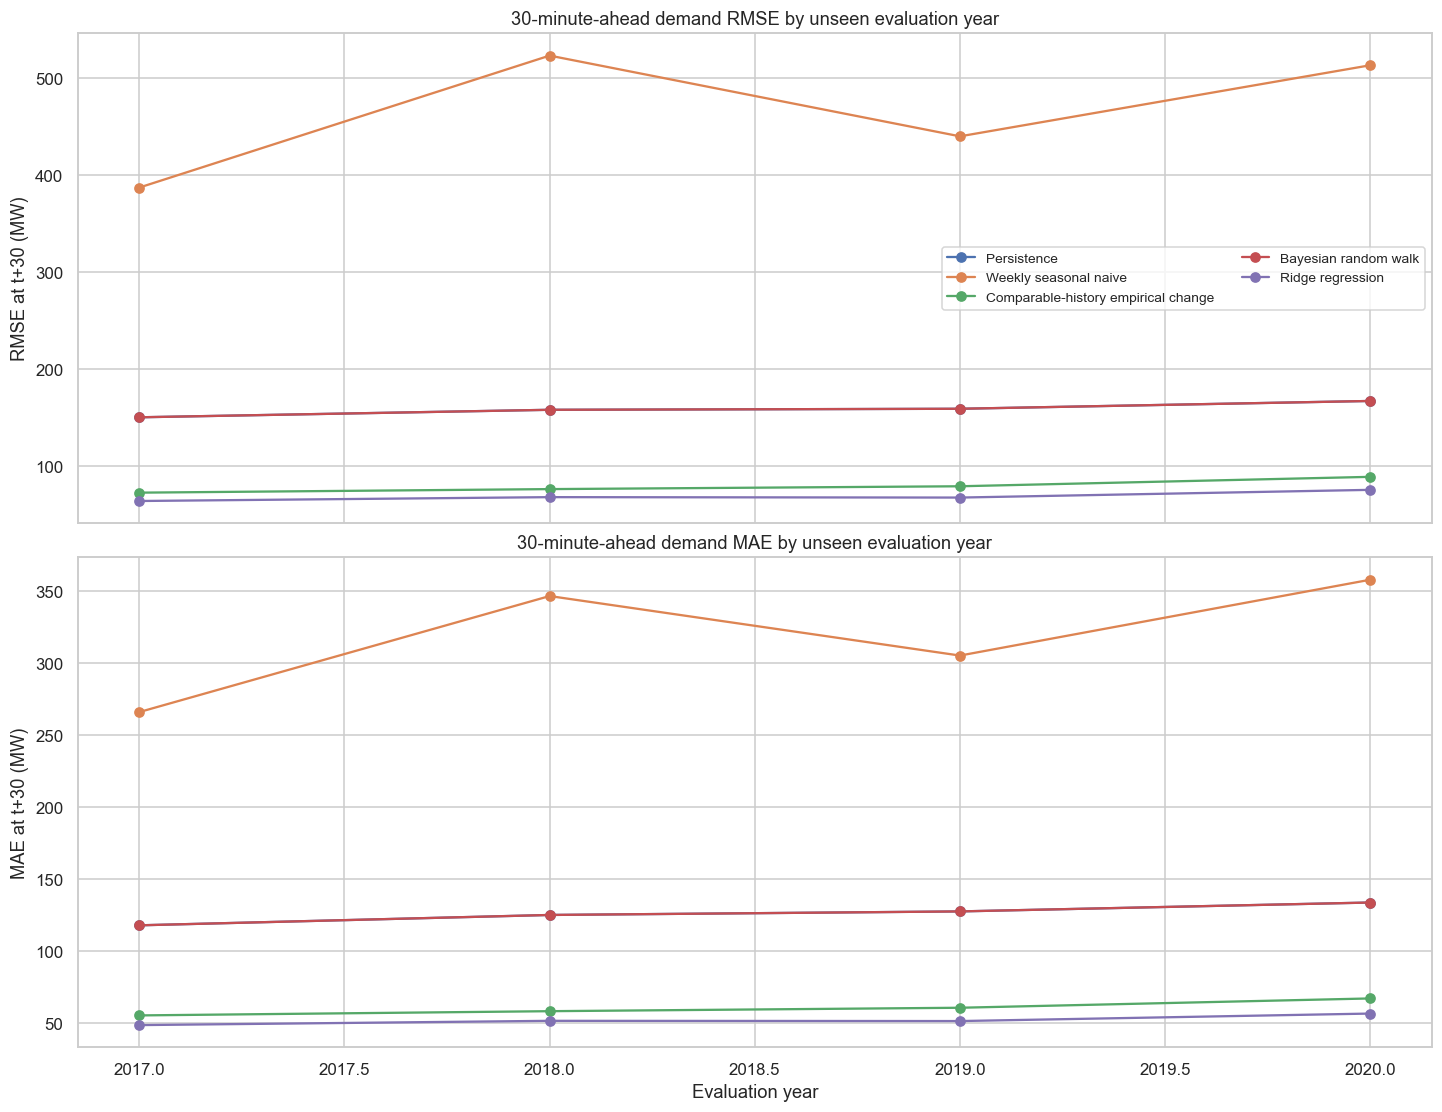

*Figure 05.1. Five-model errors for reconstructed 30-minute-ahead demand across the four expanding-window evaluation years. The modelled target is ΔD(t,30) = D(t+30) − D(t); forecasts are reconstructed as D-hat(t+30) = D(t) + ΔD-hat(t,30) before these RMSE and MAE values are calculated.*

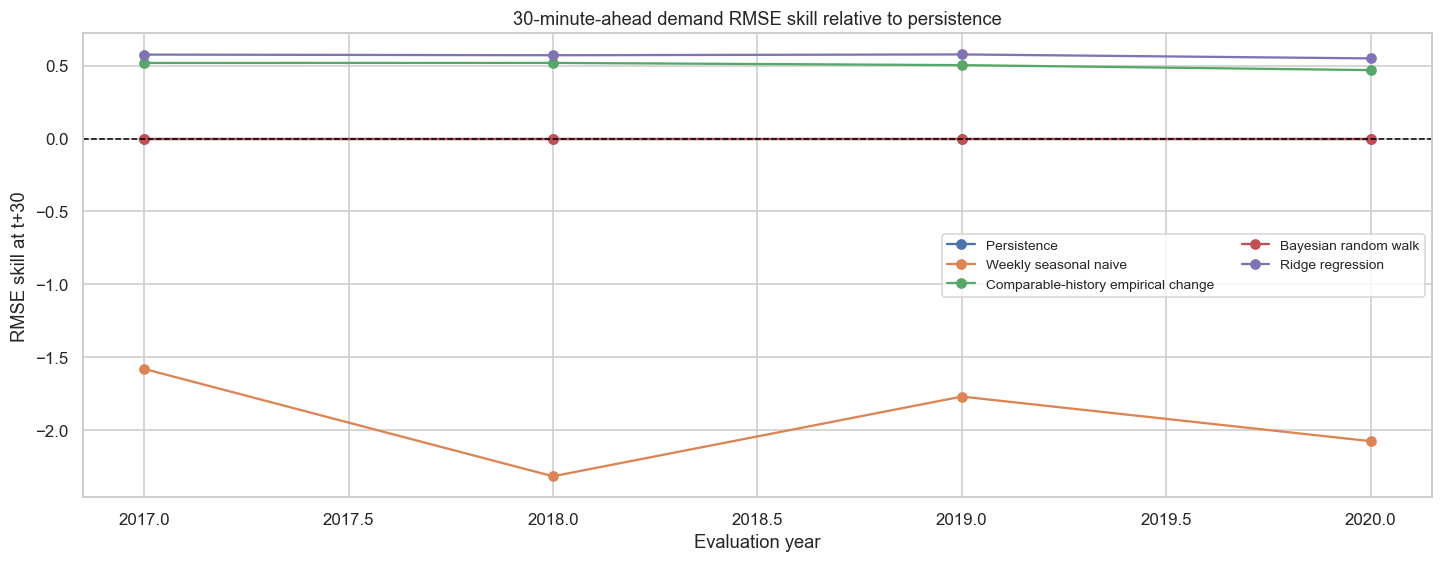

*Figure 05.2. Annual RMSE skill for reconstructed demand at t+30 relative to persistence; positive values indicate improvement. Models predict ΔD(t,30), then reconstruct D-hat(t+30) from observed D(t).*

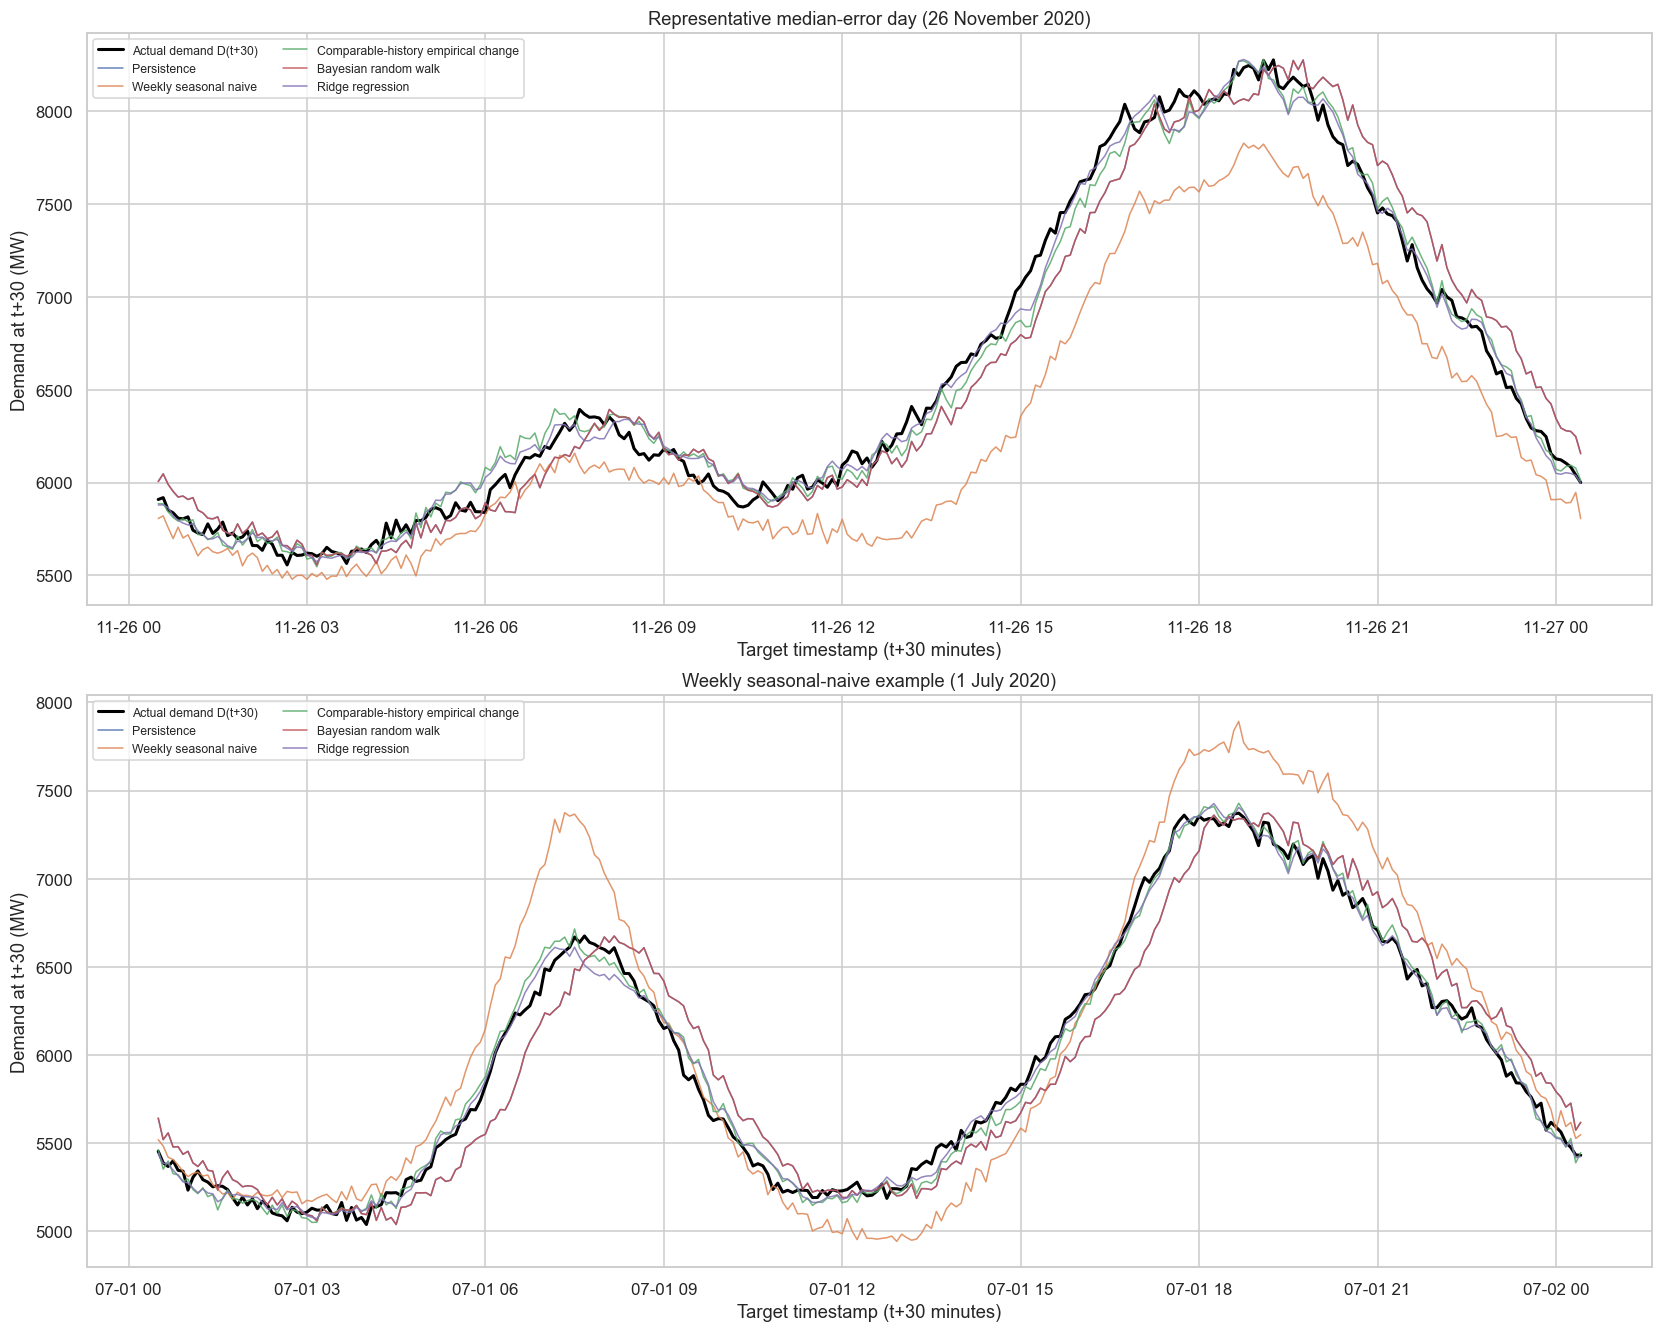

*Figure 05.3. Panel A is selected objectively as the complete 2020 day whose mean daily RMSE across all five models is closest to the median across complete days. Panel B retains 1 July as a labelled stress case: the weekly seasonal-naive forecast copies demand from the same target times on 24 June 2020, whose markedly different intraday profile causes the visible divergence. All curves show actual or reconstructed demand at t+30; the directly modelled target is ΔD(t,30).*

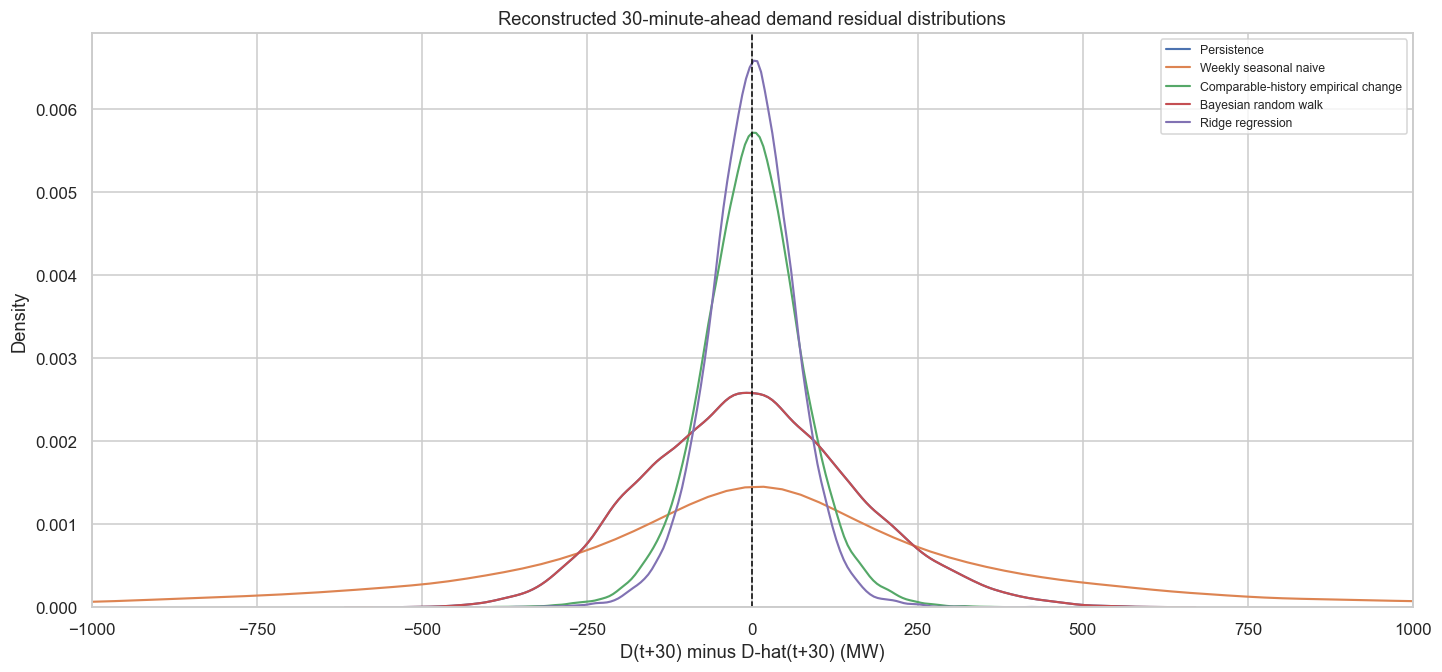

*Figure 05.4. Residual distributions for reconstructed demand at t+30 from a reproducible equal-sized sample of combined out-of-fold predictions; the directly modelled target is ΔD(t,30).*

In [8]:
plot_metrics = metrics_long.copy()
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True, constrained_layout=True)
for model_name in MODEL_ORDER:
    group = plot_metrics.loc[plot_metrics.model == model_name]
    axes[0].plot(group.evaluation_year, group.rmse_mw, marker="o", label=model_name)
    axes[1].plot(group.evaluation_year, group.mae_mw, marker="o", label=model_name)
axes[0].set(title="30-minute-ahead demand RMSE by chronologically held-out evaluation year", ylabel="RMSE at t+30 (MW)")
axes[1].set(title="30-minute-ahead demand MAE by chronologically held-out evaluation year", xlabel="Evaluation year", ylabel="MAE at t+30 (MW)")
axes[0].legend(ncol=2, fontsize=9)
plt.show()
figure_caption("Five-model errors for reconstructed 30-minute-ahead demand across the four expanding-window evaluation years. The modelled target is ΔD(t,30) = D(t+30) − D(t); forecasts are reconstructed as D-hat(t+30) = D(t) + ΔD-hat(t,30) before these RMSE and MAE values are calculated.")

fig, axis = plt.subplots(figsize=(13, 5), constrained_layout=True)
for model_name in MODEL_ORDER:
    group = skill_scores.loc[skill_scores.model == model_name]
    axis.plot(group.evaluation_year, group.rmse_skill_vs_persistence, marker="o", label=model_name)
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set(title="30-minute-ahead demand RMSE skill relative to persistence", xlabel="Evaluation year", ylabel="RMSE skill at t+30")
axis.legend(ncol=2, fontsize=9)
plt.show()
figure_caption("Annual RMSE skill for reconstructed demand at t+30 relative to persistence; positive values indicate improvement. Models predict ΔD(t,30), then reconstruct D-hat(t+30) from observed D(t).")

daily_model_errors = oof_predictions.loc[oof_predictions.evaluation_year.eq(2020)].copy()
daily_model_errors["forecast_date"] = daily_model_errors.forecast_origin.dt.normalize()
daily_model_rmse = (
    daily_model_errors.groupby(["forecast_date", "model"], observed=True)
    .agg(
        rows=("error_mw", "size"),
        daily_rmse_mw=("squared_error_mw2", lambda values: float(np.sqrt(values.mean()))),
    )
    .reset_index()
)
complete_daily_rmse = daily_model_rmse.loc[daily_model_rmse.rows.eq(288)]
daily_comparison_score = (
    complete_daily_rmse.groupby("forecast_date", observed=True)
    .agg(models=("model", "nunique"), mean_model_rmse_mw=("daily_rmse_mw", "mean"))
)
daily_comparison_score = daily_comparison_score.loc[
    daily_comparison_score.models.eq(len(MODEL_ORDER))
]
median_daily_score = daily_comparison_score.mean_model_rmse_mw.median()
representative_start = (
    daily_comparison_score.mean_model_rmse_mw.sub(median_daily_score).abs().idxmin()
)
stress_start = pd.Timestamp("2020-07-01")
representative_label = representative_start.strftime("%d %B %Y").lstrip("0")

fig, axes = plt.subplots(2, 1, figsize=(15, 12), constrained_layout=True)
window_specs = [
    (representative_start, f"Representative median-error day ({representative_label})"),
    (stress_start, "Weekly seasonal-naive example (1 July 2020)"),
]
for axis, (window_start, title) in zip(axes, window_specs):
    window_end = window_start + pd.Timedelta(days=1)
    window = oof_predictions.loc[
        oof_predictions.forecast_origin.between(window_start, window_end, inclusive="left")
    ]
    actual_line = window.loc[window.model.eq("Persistence")]
    axis.plot(
        actual_line.target_timestamp, actual_line.actual_demand_t_plus_30,
        color="black", linewidth=2, label="Actual demand D(t+30)",
    )
    for model_name in MODEL_ORDER:
        group = window.loc[window.model.eq(model_name)]
        axis.plot(
            group.target_timestamp, group.predicted_demand_t_plus_30,
            linewidth=1, alpha=0.85, label=model_name,
        )
    axis.set(
        title=title, xlabel="Target timestamp (t+30 minutes)",
        ylabel="Demand at t+30 (MW)",
    )
    axis.legend(ncol=2, fontsize=8)
plt.show()
figure_caption("Panel A is selected objectively as the complete 2020 day whose mean daily RMSE across all five models is closest to the median across complete days. Panel B retains 1 July as a labelled stress case: the weekly seasonal-naive forecast copies demand from the same target times on 24 June 2020, whose markedly different intraday profile causes the visible divergence. All curves show actual or reconstructed demand at t+30; the directly modelled target is ΔD(t,30).")

residual_sample = pd.concat([
    oof_predictions.loc[oof_predictions.model == model_name].sample(
        min(50_000, int((oof_predictions.model == model_name).sum())),
        random_state=RANDOM_SEED,
    )
    for model_name in MODEL_ORDER
], ignore_index=True)
fig, axis = plt.subplots(figsize=(13, 6), constrained_layout=True)
for model_name in MODEL_ORDER:
    values = residual_sample.loc[residual_sample.model == model_name, "error_mw"]
    sns.kdeplot(values, ax=axis, label=model_name, linewidth=1.4, cut=0)
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set(title="Reconstructed 30-minute-ahead demand residual distributions", xlabel="D(t+30) minus D-hat(t+30) (MW)", ylabel="Density", xlim=(-1000, 1000))
axis.legend(fontsize=8)
plt.show()
figure_caption("Residual distributions for reconstructed demand at t+30 from a reproducible equal-sized sample of combined out-of-fold predictions; the directly modelled target is ΔD(t,30).")

## 9. Leakage, alignment and metric-recomputation checks

In [9]:
assert len(fold_sample_sizes) == 4
assert metrics_long.fold.nunique() == 4
assert metrics_long.groupby("fold", observed=True).model.nunique().eq(5).all()
assert metrics_long.groupby("fold", observed=True).evaluation_rows.nunique().eq(1).all()
assert oof_predictions.groupby(["fold", "model"], observed=True).size().groupby(level=0).nunique().eq(1).all()
assert oof_predictions.target_timestamp.sub(oof_predictions.forecast_origin).eq(pd.Timedelta(minutes=30)).all()
assert oof_predictions.forecast_origin.max() < pd.Timestamp("2021-01-01")
assert oof_predictions.target_timestamp.max() < pd.Timestamp("2021-01-01")
assert np.isfinite(oof_predictions.predicted_demand_t_plus_30).all()
assert np.isfinite(metrics_long[["rmse_mw", "mae_mw"]]).all().all()
assert metrics_long.rmse_mw.ge(0).all() and metrics_long.mae_mw.ge(0).all()
assert len(ridge_alpha_table) == 4 and len(bayesian_diagnostics) == 4
assert ridge_alpha_table.gap_rows.ge(FORECAST_STEPS).all()

for (fold, model_name), group in oof_predictions.groupby(["fold", "model"], observed=True):
    row = metrics_long.loc[(metrics_long.fold == fold) & (metrics_long.model == model_name)].iloc[0]
    assert np.isclose(np.sqrt(group.squared_error_mw2.mean()), row.rmse_mw)
    assert np.isclose(group.absolute_error_mw.mean(), row.mae_mw)

for fold, group in oof_predictions.groupby("fold", observed=True):
    timestamp_sets = [
        pd.MultiIndex.from_frame(model_group[["forecast_origin", "target_timestamp"]])
        for _, model_group in group.groupby("model", observed=True)
    ]
    assert all(timestamp_sets[0].equals(item) for item in timestamp_sets[1:])

verification = pd.Series({
    "four_outer_folds_completed": True,
    "five_primary_models_per_fold": True,
    "identical_scored_timestamps_within_fold": True,
    "latest_forecast_origin": oof_predictions.forecast_origin.max(),
    "latest_target_timestamp": oof_predictions.target_timestamp.max(),
    "rows_from_2021_onward_used": 0,
    "demandforecast_used_as_predictor": False,
    "ridge_preprocessing_refitted_by_outer_fold": True,
    "ridge_inner_gap_rows": INNER_GAP_ROWS,
    "bayesian_posterior_refitted_from_original_prior_by_fold": True,
    "all_predictions_finite": True,
}, name="value").to_frame()
display(verification)
print("All expanding-window, target-alignment, common-sample and metric-recomputation assertions passed.")



,value
four_outer_folds_completed,True
five_primary_models_per_fold,True
identical_scored_timestamps_within_fold,True
latest_forecast_origin,2020-12-31 23:25:00
latest_target_timestamp,2020-12-31 23:55:00
rows_from_2021_onward_used,0
demandforecast_used_as_predictor,False
ridge_preprocessing_refitted_by_outer_fold,True
ridge_inner_gap_rows,6
bayesian_posterior_refitted_from_original_prior_by_fold,True


All expanding-window, target-alignment, common-sample and metric-recomputation assertions passed.


## 10. Computed findings

In [10]:
pooled_sorted_rmse = pooled.sort_values("Pooled OOF RMSE")
pooled_sorted_mae = pooled.sort_values("Pooled OOF MAE")
best_rmse_model = pooled_sorted_rmse.index[0]
best_mae_model = pooled_sorted_mae.index[0]

annual_rmse_winners = metrics_long.loc[metrics_long.groupby("fold", observed=True).rmse_mw.idxmin(), ["evaluation_year", "model"]]
annual_mae_winners = metrics_long.loc[metrics_long.groupby("fold", observed=True).mae_mw.idxmin(), ["evaluation_year", "model"]]
rmse_winner_counts = annual_rmse_winners.model.value_counts().to_dict()
mae_winner_counts = annual_mae_winners.model.value_counts().to_dict()

ridge_pooled_rmse_skill = 1 - pooled.loc["Ridge regression", "Pooled OOF RMSE"] / pooled_persistence_rmse
ridge_pooled_mae_skill = 1 - pooled.loc["Ridge regression", "Pooled OOF MAE"] / pooled_persistence_mae
never_beats_persistence = []
for model_name in MODEL_ORDER[1:]:
    rows = skill_scores.loc[skill_scores.model == model_name]
    if rows.rmse_skill_vs_persistence.le(0).all() and rows.mae_skill_vs_persistence.le(0).all():
        never_beats_persistence.append(model_name)

coverage80 = bayesian_diagnostics.interval_80_coverage.mean()
coverage95 = bayesian_diagnostics.interval_95_coverage.mean()
if coverage80 < 0.77 or coverage95 < 0.92:
    calibration_text = "under-covering"
elif coverage80 > 0.83 or coverage95 > 0.98:
    calibration_text = "conservative or unnecessarily wide"
else:
    calibration_text = "approximately calibrated at the aggregate fold level"

model_variability = metrics_long.groupby("model", observed=True).agg(min_rmse=("rmse_mw", "min"), max_rmse=("rmse_mw", "max"), min_mae=("mae_mw", "min"), max_mae=("mae_mw", "max"))
largest_rmse_range_model = (model_variability.max_rmse - model_variability.min_rmse).idxmax()
largest_rmse_range = (model_variability.max_rmse - model_variability.min_rmse).max()

display(Markdown(f'''
The best pooled out-of-fold RMSE is produced by **{best_rmse_model}** ({pooled.loc[best_rmse_model, 'Pooled OOF RMSE']:.2f} MW), while the best pooled MAE is produced by **{best_mae_model}** ({pooled.loc[best_mae_model, 'Pooled OOF MAE']:.2f} MW). Annual RMSE winners are distributed as **{rmse_winner_counts}** and annual MAE winners as **{mae_winner_counts}**, showing whether the ranking is stable or year-dependent.

Ridge has pooled skill of **{ridge_pooled_rmse_skill:.2%}** by RMSE and **{ridge_pooled_mae_skill:.2%}** by MAE relative to persistence. Models that fail to beat persistence on both metrics in every annual fold are **{never_beats_persistence if never_beats_persistence else 'none'}**.

The conjugate Bayesian random walk averages **{coverage80:.1%}** coverage for its nominal 80% interval and **{coverage95:.1%}** for its nominal 95% interval; this is assessed as **{calibration_text}**. Its Student-t posterior predictive form arises from integrating Gaussian-innovation parameter uncertainty and must not be interpreted as a fitted robust Student-t likelihood.

Performance changes materially across evaluation years: **{largest_rmse_range_model}** has the largest annual RMSE range at **{largest_rmse_range:.2f} MW**. These four chronologically held-out fold results form the minimum transparent benchmark that later deterministic and probabilistic TCN models must exceed on identical forecast origins and target timestamps.
'''))

print("Saved outputs:")
for path in sorted(OUTPUT_DIR.glob("expanding_window_*")):
    print(f" - {path.relative_to(PROJECT_ROOT)}")


The best pooled out-of-fold RMSE is produced by **Ridge regression** (68.51 MW), while the best pooled MAE is produced by **Ridge regression** (52.17 MW). Annual RMSE winners are distributed as **{'Ridge regression': 4, 'Persistence': 0, 'Weekly seasonal naive': 0, 'Comparable-history empirical change': 0, 'Bayesian random walk': 0}** and annual MAE winners as **{'Ridge regression': 4, 'Persistence': 0, 'Weekly seasonal naive': 0, 'Comparable-history empirical change': 0, 'Bayesian random walk': 0}**, showing whether the ranking is stable or year-dependent.

Ridge has pooled skill of **56.77%** by RMSE and **58.63%** by MAE relative to persistence. Models that fail to beat persistence on both metrics in every annual fold are **['Weekly seasonal naive']**.

The conjugate Bayesian random walk averages **76.4%** coverage for its nominal 80% interval and **93.4%** for its nominal 95% interval; this is assessed as **under-covering**. Its Student-t posterior predictive form arises from integrating Gaussian-innovation parameter uncertainty and must not be interpreted as a fitted robust Student-t likelihood.

Performance changes materially across evaluation years: **Weekly seasonal naive** has the largest annual RMSE range at **136.15 MW**. These four chronologically held-out fold results form the minimum transparent benchmark that later deterministic and probabilistic TCN models must exceed on identical forecast origins and target timestamps.


Saved outputs:
 - outputs\reference_models\expanding_window_bayesian_diagnostics.csv
 - outputs\reference_models\expanding_window_comparable_history_fallbacks.csv
 - outputs\reference_models\expanding_window_five_model_rmse_mae.csv
 - outputs\reference_models\expanding_window_fold_sample_sizes.csv
 - outputs\reference_models\expanding_window_metrics_long.csv
 - outputs\reference_models\expanding_window_model_feature_contract.csv
 - outputs\reference_models\expanding_window_oof_predictions.parquet
 - outputs\reference_models\expanding_window_ridge_alphas.csv
 - outputs\reference_models\expanding_window_ridge_inner_scores.csv
 - outputs\reference_models\expanding_window_skill_scores.csv


## 11. Interpretation boundary

These are transparent 30-minute reference models. Their role is to establish reproducible baselines before the TCN family is compared on an exactly matched year, horizon and timestamp set. A 2020 result must not be presented as a direct comparison with a 2019 TCN result, and vice versa.
        